## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import search_model as sm

/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:3649: RuntimeWarning: overflow encountered in exp
  return -x - np.exp(-x)


## Utility

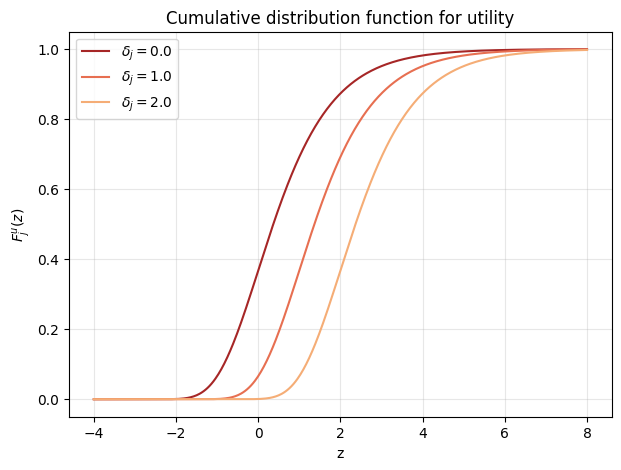

In [2]:
z_grid = np.linspace(-4, 8, 500)
delta_values = [0.0, 1.0, 2.0]
colors = ['#a62626', '#e76f51', '#f5ad76']

plt.figure(figsize=(7, 5))
for delta_j, color in zip(delta_values, colors):
    plt.plot(
        z_grid,
        sm.F_u(z_grid, delta_j),
        label=fr"$\delta_j={delta_j}$",
        color=color
    )

plt.xlabel("z")
plt.ylabel(r"$F_j^u(z)$")
plt.title("Cumulative distribution function for utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Expected gain

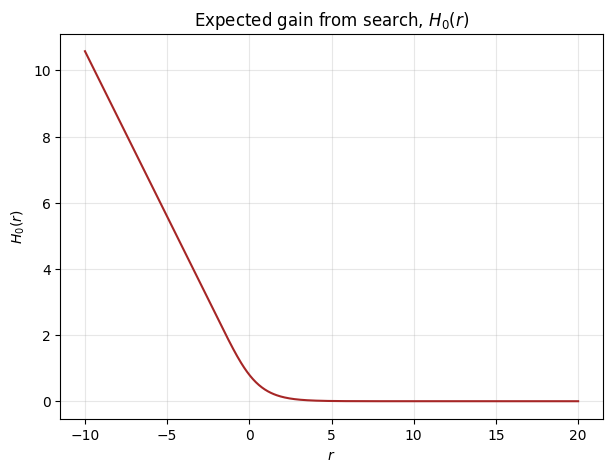

In [8]:
zz = np.linspace(-10, 20, 500)
H0_vals = sm.H0_vec(zz)

plt.figure(figsize=(7, 5))
plt.plot(zz, H0_vals, color="#a62626")

plt.xlabel(r"$r$")
plt.ylabel(r"$H_0(r)$")
plt.title(r"Expected gain from search, $H_0(r)$")
plt.grid(True, alpha=0.3)
plt.show()

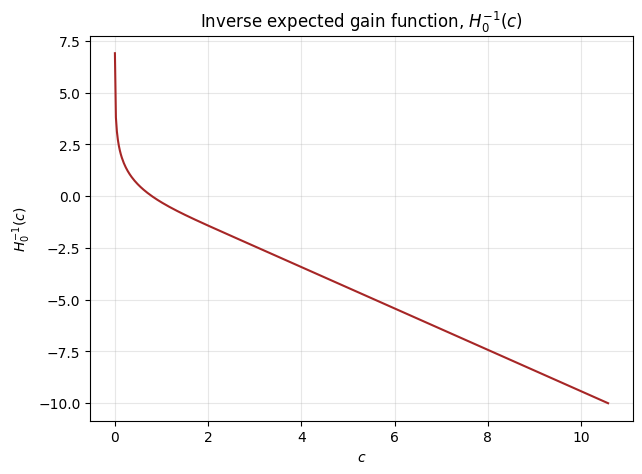

In [9]:
c_grid = np.linspace(0.001, H0_vals.max(), 500)
z_from_c = sm.H0_inv_vec(c_grid)

plt.figure(figsize=(7, 5))
plt.plot(c_grid, z_from_c, color="#a62626")

plt.xlabel(r"$c$")
plt.ylabel(r"$H_0^{-1}(c)$")
plt.title(r"Inverse expected gain function, $H_0^{-1}(c)$")
plt.grid(True, alpha=0.3)
plt.show()

## Weitzman

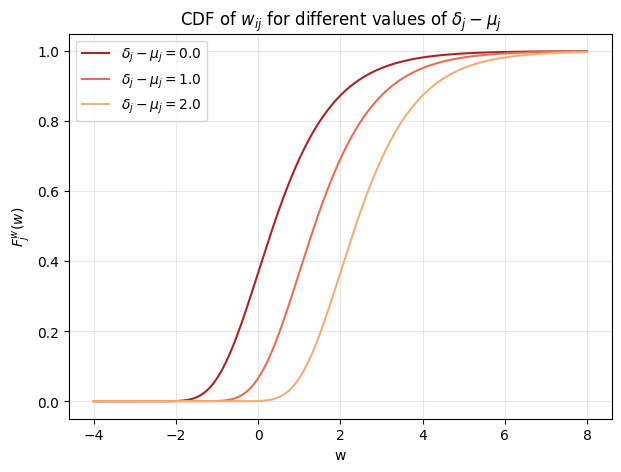

In [16]:
z_grid = np.linspace(-4, 8, 500)
lambda_values = [0.0, 1.0, 2.0] 
colors = ['#a62626', '#e76f51', '#f5ad76']

plt.figure(figsize=(7, 5))

for lam, color in zip(lambda_values, colors):
    mu_j = 1.0
    delta_j = lam + mu_j
    
    plt.plot(
        z_grid,
        sm.F_w(z_grid, delta_j, mu_j),
        label=fr"$\delta_j - \mu_j = {lam}$", 
        color=color
    )

plt.xlabel("w")
plt.ylabel(r"$F_j^w(w)$")
plt.title(r"CDF of $w_{ij}$ for different values of $\delta_j - \mu_j$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Search cost

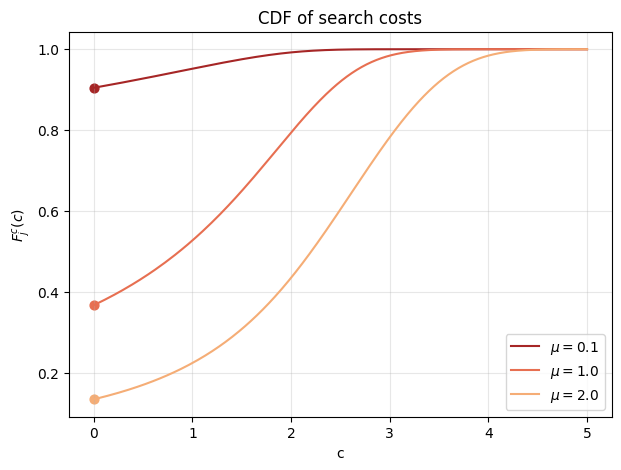

In [22]:
c_grid = np.linspace(0, 5, 500)
mu_values = [0.1, 1.0, 2.0]
colors = ['#a62626', '#e76f51', '#f5ad76']

plt.figure(figsize=(7, 5))

for mu, color in zip(mu_values, colors):
    Fc_vals = np.array([sm.Fc(c, mu) for c in c_grid])
    plt.plot(c_grid, Fc_vals, label=fr"$\mu={mu}$", color=color)
    plt.scatter([0], [sm.Fc(0.0, mu)], s=40, color=color)

plt.xlabel("c")
plt.ylabel(r"$F^c_j(c)$")
plt.title("CDF of search costs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Reservation value

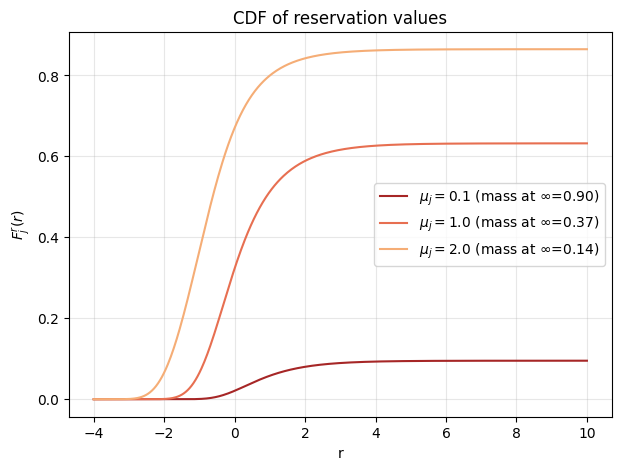

In [27]:
r_grid = np.linspace(-4, 10, 500)
delta_j = 1.0
mu_values = [0.1, 1.0, 2.0]
colors = ['#a62626', '#e76f51', '#f5ad76']

plt.figure(figsize=(7, 5))

for mu_j, color in zip(mu_values, colors):
    Fr_vals = sm.F_r(r_grid, delta_j, mu_j)
    plt.plot(
        r_grid,
        Fr_vals,
        label=fr"$\mu_j={mu_j}$ (mass at $\infty$={np.exp(-mu_j):.2f})", 
        color=color
    )

plt.xlabel("r")
plt.ylabel(r"$F_j^r(r)$")
plt.title("CDF of reservation values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

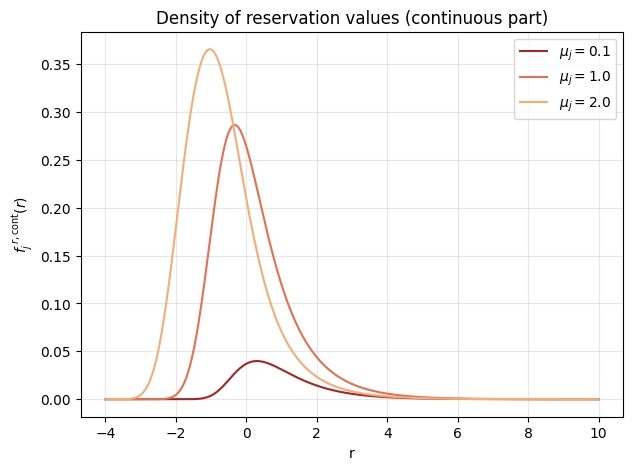

In [29]:
plt.figure(figsize=(7, 5))
colors = ['#a62626', '#e76f51', '#f5ad76']

for mu_j, color in zip(mu_values, colors):
    fr_vals = sm.f_r_cont(r_grid, delta_j, mu_j)
    plt.plot(r_grid, fr_vals, label=fr"$\mu_j={mu_j}$", 
             color=color)

plt.xlabel("r")
plt.ylabel(r"$f_j^{\ r,\mathrm{cont}}(r)$")
plt.title("Density of reservation values (continuous part)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()